In [140]:
from qiskit.quantum_info import random_clifford, StabilizerState
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import random_clifford, Pauli, Statevector

In [57]:
def corr(P1, P2, n_samples):
    
    n = len(P1.to_label())

    ev1 = []
    ev2 = []

    for _ in range(n_samples):
        C = random_clifford(n)
        rho = StabilizerState(C)
        
        ev1.append(rho.expectation_value(P1))
        ev2.append(rho.expectation_value(P2))

    v1 = np.abs(np.array(ev1))
    v2 = np.abs(np.array(ev2))
    
    return (v1 * v2).mean()

In [162]:
n_samples = 50000
n = range(2, 5+1)
c = []
for i in n:
    P1 = Pauli('Z' + 'I'*(i-1))
    P2 = Pauli('I'+'Z' + 'I'*(i-2))
    
    c.append(corr(P1, P2, n_samples))

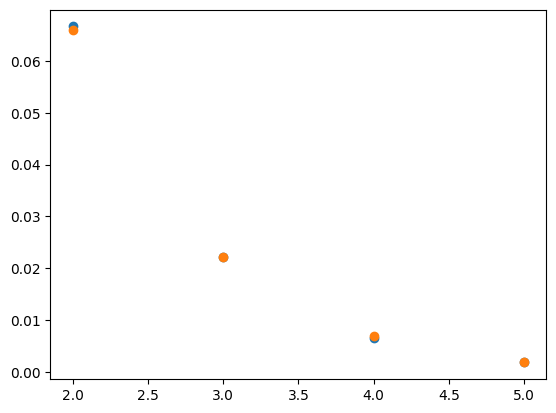

In [163]:
def pred(n):
    return (2**n-2)/(2**(2*n-1)-2) * (2**n-1)/(4**n-1)

plt.scatter(n, [pred(i) for i in n])
plt.scatter(n, c)

In [153]:
n = 2
n_samples = 50000

P1 = Pauli('ZI')   
P2 = Pauli('IZ')   

res = defaultdict(lambda: defaultdict(int))
for _ in range(n_samples):
    C = random_clifford(n)
    Q1 = P1.evolve(C)
    Q1.phase = 0
    Q2 = P2.evolve(C)
    Q2.phase = 0
        
    res[Q1.to_label()][Q2.to_label()] += 1

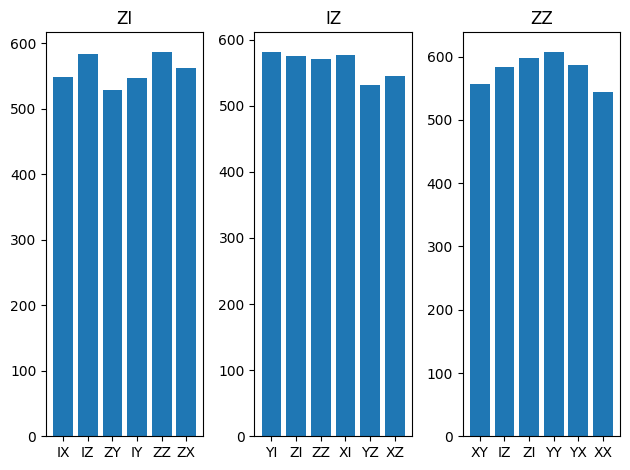

In [154]:
fig, axes = plt.subplots(1, 3)

labels = ('ZI', 'IZ', 'ZZ')
for ax, label in zip(axes, labels):
    ax.bar(res[label].keys(), res[label].values())
    ax.set_title(label)

plt.tight_layout()